In [1]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt

In [2]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS=3
EPOCHS=5

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    shuffle=True,
    image_size = (IMAGE_SIZE,IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 10254 files belonging to 8 classes.


In [4]:
class_names = dataset.class_names
class_names

['Pepper__bell___Bacterial_spot',
 'Pepper__bell___healthy',
 'Potato___Late_blight',
 'Potato___healthy',
 'Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_healthy']

In [5]:
len(dataset)

321

In [6]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

(32, 256, 256, 3)
[7 4 7 5 6 1 4 4 2 5 7 4 1 0 6 7 5 6 7 4 4 5 7 2 0 5 6 6 1 4 6 4]


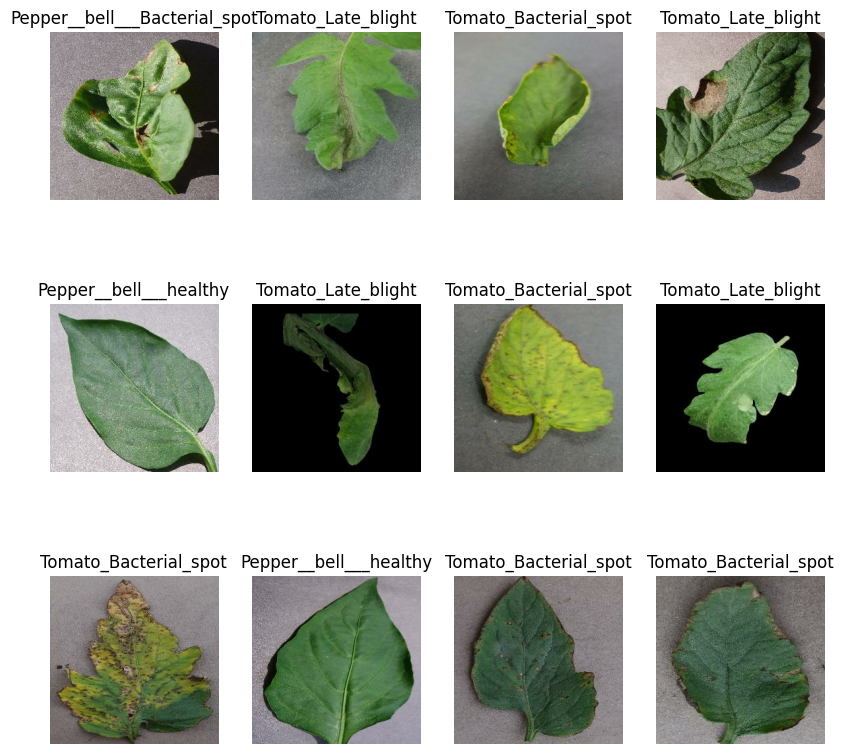

In [7]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

In [8]:
train_size = 0.8
len(dataset)*train_size

256.8

In [9]:
train_ds = dataset.take(256)
len(train_ds)

256

In [10]:
test_ds = dataset.skip(256)
len(test_ds)

65

In [11]:
val_size=0.1
len(dataset)*val_size

32.1

In [12]:
val_ds = test_ds.take(32)
len(val_ds)

32

In [13]:
test_ds = test_ds.skip(32)
len(test_ds)

33

In [14]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [15]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [16]:
len(train_ds)

256

In [17]:
len(val_ds)

32

In [18]:
len(test_ds)

33

In [19]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [20]:
resize_and_rescale = tf.keras.Sequential([
  layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  layers.experimental.preprocessing.Rescaling(1./255),
])

In [21]:
data_augmentation = tf.keras.Sequential([
  layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
  layers.experimental.preprocessing.RandomRotation(0.2),
])

In [34]:
from tensorflow.keras import layers, models

input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 8 

model = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)


In [35]:
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 256, 256, 3)       0         
                                                                 
 conv2d_17 (Conv2D)          (32, 254, 254, 32)        896       
                                                                 
 max_pooling2d_15 (MaxPooli  (32, 127, 127, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_18 (Conv2D)          (32, 125, 125, 64)        18496     
                                                                 
 max_pooling2d_16 (MaxPooli  (32, 62, 62, 64)          0         
 ng2D)                                                           
                                                                 
 conv2d_19 (Conv2D)          (32, 60, 60, 64)         

In [36]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [37]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=5,
)

Epoch 1/5
256/256 [==============================] - 261s 1s/step - loss: 1.1953 - accuracy: 0.5762 - val_loss: 0.7109 - val_accuracy: 0.7549
Epoch 2/5
256/256 [==============================] - 225s 877ms/step - loss: 0.5967 - accuracy: 0.7879 - val_loss: 0.4147 - val_accuracy: 0.8447
Epoch 3/5
256/256 [==============================] - 212s 827ms/step - loss: 0.4027 - accuracy: 0.8566 - val_loss: 0.2990 - val_accuracy: 0.9004
Epoch 4/5
256/256 [==============================] - 207s 808ms/step - loss: 0.2899 - accuracy: 0.8961 - val_loss: 0.1900 - val_accuracy: 0.9326
Epoch 5/5
256/256 [==============================] - 205s 801ms/step - loss: 0.2194 - accuracy: 0.9212 - val_loss: 0.2307 - val_accuracy: 0.9150


In [38]:
scores = model.evaluate(test_ds)

33/33 [==============================] - 56s 315ms/step - loss: 0.2219 - accuracy: 0.9242


In [39]:
scores

[0.22185230255126953, 0.9242424368858337]

In [40]:
history

In [41]:
history.params

{'verbose': 1, 'epochs': 5, 'steps': 256}

In [42]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [43]:
type(history.history['loss'])

list

In [44]:
history.history['loss'][:5]

[1.1952872276306152,
 0.5966563820838928,
 0.4026831388473511,
 0.28987744450569153,
 0.2194403111934662]

In [45]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

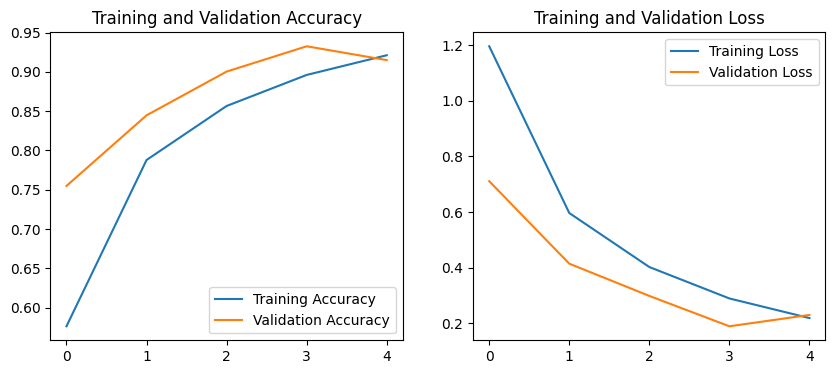

In [46]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

first image to predict
actual label: Tomato_healthy
1/1 [==============================] - 1s 640ms/step
predicted label: Tomato_healthy


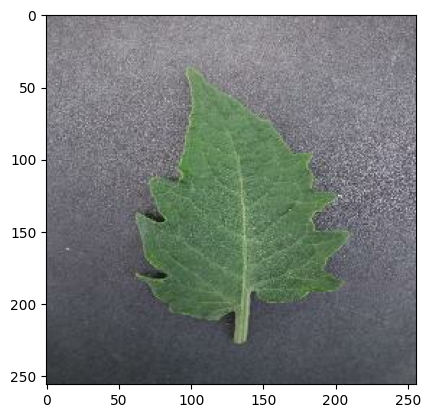

In [47]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

In [48]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 [==============================] - 0s 20ms/step


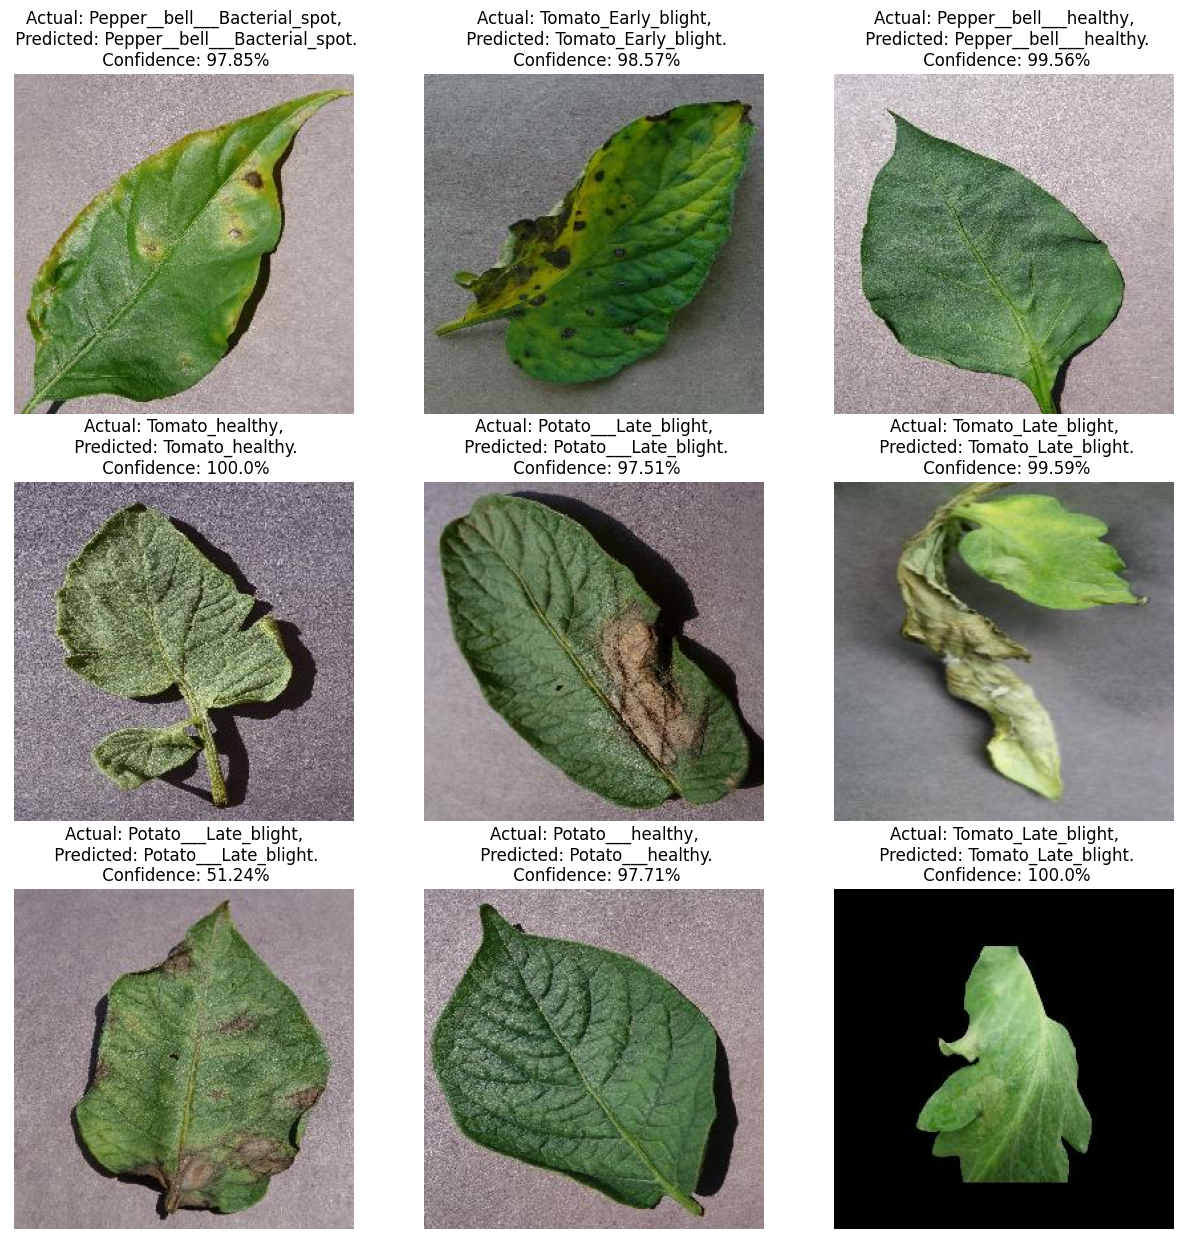

In [49]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

In [51]:
import cv2

Path of the image to be predicted:  C:\Users\harsh\deep_learn\plant-disease\train\PlantVillage\Tomato_Late_blight\0a39aa48-3f94-4696-9e43-ff4a93529dc3___RS_Late.B 5103.JPG


1/1 [==============================] - 1s 623ms/step
Prediction probabilities: [[3.1658104e-14 4.0197603e-26 1.5896419e-30 0.0000000e+00 3.2828337e-35
  1.0637556e-15 1.0000000e+00 1.5308796e-30]]


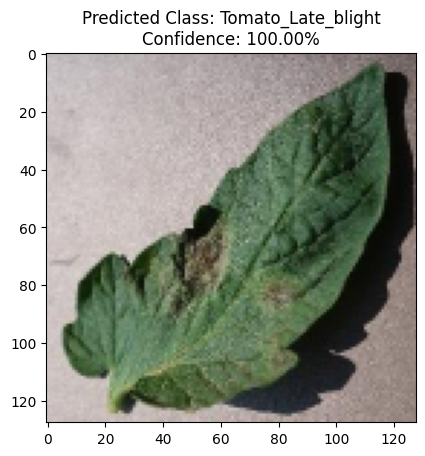

In [52]:
input_image_path = input('Path of the image to be predicted: ')
input_image = cv2.imread(input_image_path)

if input_image is None:
    print("Error: Unable to load the image.")
else:
    input_image_resized = cv2.resize(input_image, (128, 128))
    input_image_scaled = input_image_resized / 255
    input_image_reshaped = np.reshape(input_image_scaled, [1, 128, 128, 3])
    input_prediction = model.predict(input_image_reshaped)
    input_pred_label = np.argmax(input_prediction)

    print("Prediction probabilities:", input_prediction)

    class_labels = ['Pepper__bell___Bacterial_spot',
 'Pepper__bell___healthy',
 'Potato___Late_blight',
 'Potato___healthy',
 'Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_healthy']

    plt.imshow(cv2.cvtColor(input_image_resized, cv2.COLOR_BGR2RGB))
    plt.title(f'Predicted Class: {class_labels[input_pred_label]}\nConfidence: {input_prediction[0, input_pred_label]:.2%}')
    plt.show()
